In [1]:
import pandas as pd

X_train = pd.read_csv("../data/processed/X_train.csv", index_col=0)
X_val   = pd.read_csv("../data/processed/X_val.csv", index_col=0)
X_test  = pd.read_csv("../data/processed/X_test.csv", index_col=0)

In [2]:
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_val = pd.read_csv("../data/processed/y_val.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
model = HistGradientBoostingClassifier(class_weight="balanced", max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_val_pred = model.predict(X_val)

In [4]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_val, y_val_pred))
print("F1 Score:", f1_score(y_val, y_val_pred, average="macro"))

Accuracy: 0.8726959352707425
Balanced Accuracy: 0.5241079186205713
F1 Score: 0.5070786334520907


In [7]:
from sklearn.metrics import classification_report
classification_report(y_val, y_val_pred)
print(classification_report(y_val, y_val_pred))

                    precision    recall  f1-score   support

         ascending       0.61      0.43      0.50       263
           central       0.81      0.89      0.85      4857
        descending       0.35      0.20      0.25       196
         endocrine       0.09      0.42      0.14        12
             motor       0.29      0.44      0.35        16
             optic       0.93      0.94      0.93     11680
           sensory       0.90      0.88      0.89      2540
 sensory_ascending       0.36      0.34      0.35        92
visual_centrifugal       0.23      0.27      0.25        78
 visual_projection       0.75      0.45      0.56      1153

          accuracy                           0.87     20887
         macro avg       0.53      0.52      0.51     20887
      weighted avg       0.87      0.87      0.87     20887



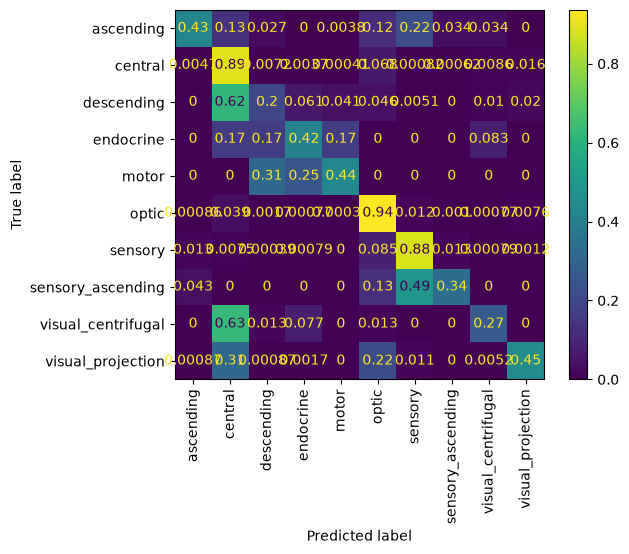

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred, normalize="true", xticks_rotation=90)

In [ ]:
import os
import matplotlib.pyplot as plt

os.makedirs("../results", exist_ok=True)
plt.gcf().savefig("../results/confusion_boosting_v1.png", dpi=150, bbox_inches="tight")

## Gradient Boosting results

On the validation set:

- Accuracy: 0.873
- Balanced accuracy: 0.524
- Macro F1: 0.507

Compared to the Logistic Regression baseline (accuracy 0.683, balanced accuracy 0.676, macro F1 0.374), boosting is a large improvement on accuracy and macro F1, but a drop on balanced accuracy. This means boosting is much better on the large classes (`optic`, `sensory`, `central`) — where most of the data lives — but recovers fewer of the rare classes than the balanced-weight logistic regression did.

The confusion matrix shows where the rare-class errors go:

- `visual_projection` → `central` 31%, → `optic` 22%
- `descending` → `central` 62%
- `visual_centrifugal` → `central` 63%
- `sensory_ascending` → `sensory` 49%

These are not random mistakes: in every case, the misclassified class is one whose definition depends on **where in the brain the neuron projects to or from** (e.g. descending, visual-centrifugal, ascending), and it gets absorbed into a broad, location-agnostic class (`central`, `optic`, `sensory`). The current features (partner counts, synapse counts, size, output neurotransmitter mix) carry no information about *which brain region* a neuron connects to — only *how much* it connects. The natural next step is adding features that capture synapses per neuropil, so the model has a chance to distinguish neurons by their spatial connectivity pattern, not just its magnitude.